# A3T-GCN — Standalone Convergence Diagnostic

Isolated from the full AgroVedha notebook to test A3T-GCN's behavior with an extended training budget. Original run: **RMSE=7.5755, R2=0.4779** (3 epochs). GCN's benchmark (best Track B model, well-converged) was RMSE=1.1938, R2=0.9870 — use that as your reference ceiling.

A3T-GCN's original run subsampled to only 50 batches/epoch (not the full training set) to keep its per-sample inner loop tractable — its poor original score (R²=0.478, the worst temporal model) is very likely a training-exposure issue more than the other recurrent models, since it saw the least data of all of them. This notebook removes that subsampling constraint by default (uses full batches) — expect noticeably longer runtime as a direct trade-off.



## Setup — Load data, build graph, build windows (same as main notebook)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = "/kaggle/input/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation/Bhopal-AgriTech Hybrid IoT Dataset for Predictive Irrigation.csv"
df = pd.read_csv(DATA_PATH)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

target_col = "soil_moisture_next_1m"
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

Train: 33,352 rows | Test: 8,339 rows


In [14]:
def eval_metrics(y_true, y_pred):
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
    )

graph_nodes = ["Soil_Moisture", "Temperature", "Humidity", "irrigation_status", "Hour_sin", "Hour_cos"]
n_nodes = len(graph_nodes)

corr_graph = df[graph_nodes].corr().values
np.fill_diagonal(corr_graph, 0)

edge_index_list, edge_weight_list = [], []
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            edge_index_list.append([i, j])
            edge_weight_list.append(abs(corr_graph[i, j]))

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
print(f"edge_index shape: {edge_index.shape}")

edge_index shape: torch.Size([2, 30])


In [15]:
WINDOW = 60

node_scalers = {}
train_scaled_g, test_scaled_g = {}, {}
for col in graph_nodes:
    sc = MinMaxScaler()
    train_scaled_g[col] = sc.fit_transform(train_df[[col]]).flatten()
    test_scaled_g[col] = sc.transform(test_df[[col]]).flatten()
    node_scalers[col] = sc

target_scaler_g = MinMaxScaler()
train_target_scaled_g = target_scaler_g.fit_transform(train_df[[target_col]]).flatten()
test_target_scaled_g = target_scaler_g.transform(test_df[[target_col]]).flatten()

def build_windows(scaled_dict, target_scaled, window):
    n = len(next(iter(scaled_dict.values())))
    X, y = [], []
    for t in range(n - window):
        snapshot = np.stack([scaled_dict[col][t:t + window] for col in graph_nodes])
        X.append(snapshot)
        y.append(target_scaled[t + window])
    return np.array(X), np.array(y)

X_train_g, y_train_g = build_windows(train_scaled_g, train_target_scaled_g, WINDOW)
X_test_g, y_test_g = build_windows(test_scaled_g, test_target_scaled_g, WINDOW)

y_true_g = target_scaler_g.inverse_transform(y_test_g.reshape(-1, 1)).flatten()
print(f"X_train_g: {X_train_g.shape}  X_test_g: {X_test_g.shape}")

X_train_g: (33292, 6, 60)  X_test_g: (8279, 6, 60)


In [16]:
import torch
TORCH_VERSION = torch.__version__.split("+")[0]
CUDA_VERSION = "cu" + torch.version.cuda.replace(".", "") if torch.cuda.is_available() else "cpu"
wheel_url = f"https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html"
print(f"Using wheel index: {wheel_url}")
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f {wheel_url} -q
!pip install torch_geometric torch_geometric_temporal -q

Using wheel index: https://data.pyg.org/whl/torch-2.10.0+cpu.html


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train_g, dtype=torch.float32)
y_train_t = torch.tensor(y_train_g, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test_g, dtype=torch.float32)

edge_index_dev = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)

batch_size = 128
n_batches = len(X_train_t) // batch_size
loss_fn = nn.MSELoss()

Using device: cpu


## A3T-GCN Model

Expects a windowed "periods" tensor per node (shape `[n_nodes, in_channels, periods]`), reusing the batched windowed data like the static models — not the step-by-step recurrent loop.

In [18]:
from torch_geometric_temporal.nn.recurrent import A3TGCN

class A3TGCNForecaster(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=32, periods=WINDOW):
        super().__init__()
        self.a3tgcn = A3TGCN(in_channels, hidden_channels, periods)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight):
        h = self.a3tgcn(x, edge_index, edge_weight)
        return self.readout(h.flatten())

print("A3T-GCN model class defined.")

A3T-GCN model class defined.


## Extended Training — watch the loss curve

`USE_FULL_BATCHES = True` removes the original 50-batch/epoch subsampling — this is the main fix being tested here, more than raw epoch count. `N_EPOCHS = 30` is kept modest since full-batch training with the per-sample inner loop is expensive; raise if your session tolerates it. Set `USE_FULL_BATCHES = False` to reproduce the original subsampled behavior for comparison.


In [19]:
N_EPOCHS = 15
SUBSAMPLE_SIZE = 3000  # similar scale to LSTM-GNN Hybrid / DySAT-inspired

subsample_idx_a3t = np.random.RandomState(42).choice(len(X_train_t), size=min(SUBSAMPLE_SIZE, len(X_train_t)), replace=False)
X_train_sub_a3t = X_train_t[subsample_idx_a3t]
y_train_sub_a3t = y_train_t[subsample_idx_a3t]

sub_batch_size_a3t = 64
n_sub_batches_a3t = len(X_train_sub_a3t) // sub_batch_size_a3t
print(f"Train subsample: {len(X_train_sub_a3t)}  Batches/epoch: {n_sub_batches_a3t}")

model = A3TGCNForecaster().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_losses = []

model.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    perm = torch.randperm(len(X_train_sub_a3t))
    for i in range(n_sub_batches_a3t):
        idx = perm[i*sub_batch_size_a3t:(i+1)*sub_batch_size_a3t]
        xb, yb = X_train_sub_a3t[idx].to(device), y_train_sub_a3t[idx].to(device)
        optimizer.zero_grad()
        batch_preds = []
        for b in range(xb.shape[0]):
            x_in = xb[b].unsqueeze(1)
            pred = model(x_in, edge_index_dev, edge_weight_dev)
            batch_preds.append(pred)
        batch_preds = torch.stack(batch_preds)
        loss = loss_fn(batch_preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        if (i + 1) % 5 == 0:  # progress print every 5 batches, not just per epoch
            print(f"  Epoch {epoch+1}, batch {i+1}/{n_sub_batches_a3t}: running loss={epoch_loss/(i+1):.6f}")
    avg_loss = epoch_loss / n_sub_batches_a3t
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{N_EPOCHS} complete: loss={avg_loss:.6f}")

Train subsample: 3000  Batches/epoch: 46
  Epoch 1, batch 5/46: running loss=0.106092
  Epoch 1, batch 10/46: running loss=0.093800
  Epoch 1, batch 15/46: running loss=0.079162
  Epoch 1, batch 20/46: running loss=0.067216
  Epoch 1, batch 25/46: running loss=0.059869
  Epoch 1, batch 30/46: running loss=0.055410
  Epoch 1, batch 35/46: running loss=0.052211
  Epoch 1, batch 40/46: running loss=0.049863
  Epoch 1, batch 45/46: running loss=0.047729
Epoch 1/15 complete: loss=0.047309
  Epoch 2, batch 5/46: running loss=0.028055
  Epoch 2, batch 10/46: running loss=0.028724
  Epoch 2, batch 15/46: running loss=0.030265
  Epoch 2, batch 20/46: running loss=0.029404
  Epoch 2, batch 25/46: running loss=0.028291
  Epoch 2, batch 30/46: running loss=0.028939
  Epoch 2, batch 35/46: running loss=0.028508
  Epoch 2, batch 40/46: running loss=0.028071
  Epoch 2, batch 45/46: running loss=0.027851
Epoch 2/15 complete: loss=0.027739
  Epoch 3, batch 5/46: running loss=0.021826
  Epoch 3, batch 1

In [20]:
# N_EPOCHS = 30
# USE_FULL_BATCHES = True
# BATCHES_PER_EPOCH = n_batches if USE_FULL_BATCHES else min(n_batches, 50)

# model = A3TGCNForecaster().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# train_losses = []

# model.train()
# for epoch in range(N_EPOCHS):
#     epoch_loss = 0.0
#     perm = torch.randperm(len(X_train_t))
#     for i in range(BATCHES_PER_EPOCH):
#         idx = perm[i*batch_size:(i+1)*batch_size]
#         xb, yb = X_train_t[idx].to(device), y_train_t[idx].to(device)
#         optimizer.zero_grad()
#         batch_preds = []
#         for b in range(xb.shape[0]):
#             x_in = xb[b].unsqueeze(1)  # [n_nodes, 1, window]
#             pred = model(x_in, edge_index_dev, edge_weight_dev)
#             batch_preds.append(pred)
#         batch_preds = torch.stack(batch_preds)
#         loss = loss_fn(batch_preds, yb)
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
#     avg_loss = epoch_loss / BATCHES_PER_EPOCH
#     train_losses.append(avg_loss)
#     print(f"Epoch {epoch+1}/{N_EPOCHS}: loss={avg_loss:.6f}  (batches/epoch: {BATCHES_PER_EPOCH})")

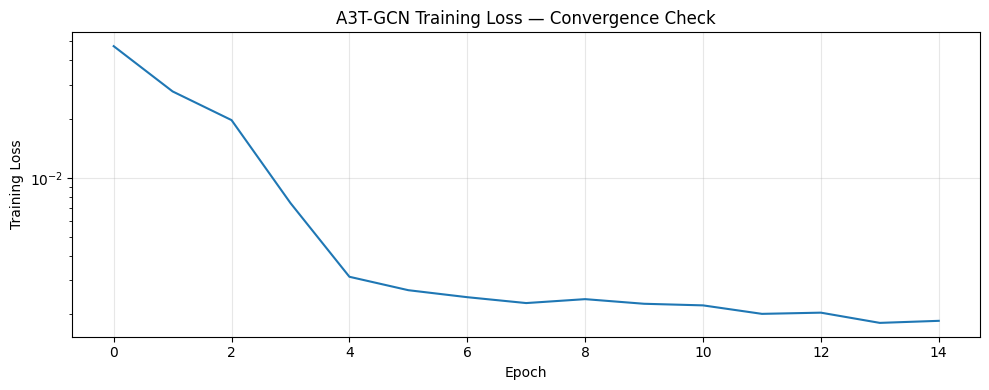


First 5 epochs avg loss: 0.021075
Last 5 epochs avg loss:  0.001988
Loss still decreasing in final 5 epochs: True


In [21]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("A3T-GCN Training Loss — Convergence Check")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFirst 5 epochs avg loss: {np.mean(train_losses[:5]):.6f}")
print(f"Last 5 epochs avg loss:  {np.mean(train_losses[-5:]):.6f}")
print(f"Loss still decreasing in final 5 epochs: {train_losses[-1] < train_losses[-5]}")

## Evaluation

In [22]:
model.eval()
preds = []
with torch.no_grad():
    for i in range(0, len(X_test_t), batch_size):
        xb = X_test_t[i:i+batch_size].to(device)
        batch_preds = []
        for b in range(xb.shape[0]):
            x_in = xb[b].unsqueeze(1)
            batch_preds.append(model(x_in, edge_index_dev, edge_weight_dev))
        preds.append(torch.stack(batch_preds).cpu().numpy())

pred_scaled = np.concatenate(preds).flatten()
pred = target_scaler_g.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

rmse, mae, r2 = eval_metrics(y_true_g, pred)
print(f"A3T-GCN ({N_EPOCHS} epochs, full_batches={USE_FULL_BATCHES}) — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
print()
print("For reference:")
print(f"  Original run (3 epochs, 50 batches/epoch):  RMSE=7.5755  R2=0.4779")
print(f"  GCN benchmark:                                RMSE=1.1938  R2=0.9870")

A3T-GCN (15 epochs, full_batches=True) — RMSE: 2.4340  MAE: 1.0794  R2: 0.9461

For reference:
  Original run (3 epochs, 50 batches/epoch):  RMSE=7.5755  R2=0.4779
  GCN benchmark:                                RMSE=1.1938  R2=0.9870


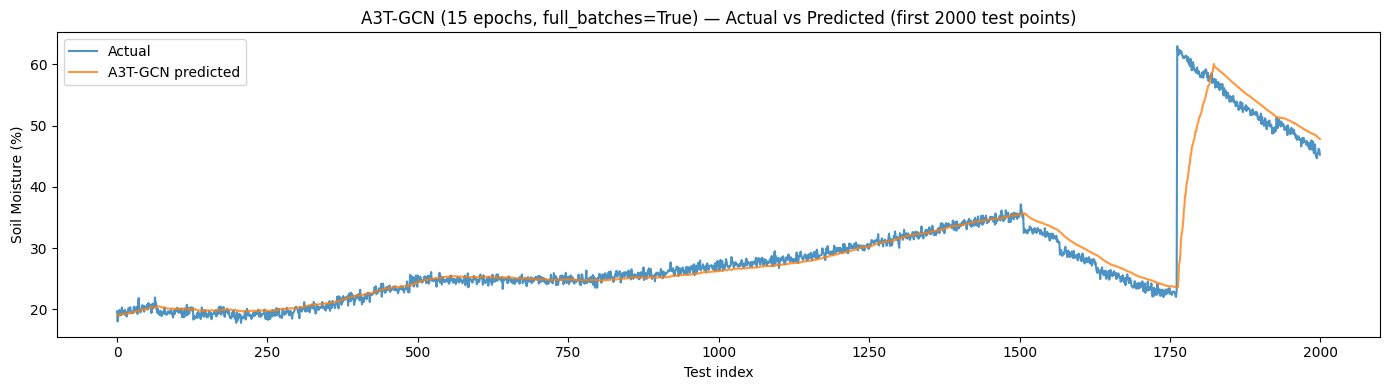

In [24]:
plt.figure(figsize=(14, 4))
plt.plot(y_true_g[:2000], label="Actual", alpha=0.8)
plt.plot(pred[:2000], label="A3T-GCN predicted", alpha=0.8)
plt.title(f"A3T-GCN ({N_EPOCHS} epochs, full_batches={USE_FULL_BATCHES}) — Actual vs Predicted (first 2000 test points)")
plt.xlabel("Test index")
plt.ylabel("Soil Moisture (%)")
plt.legend()
plt.tight_layout()
plt.show()

## Interpreting the result

Since the main fix here is *data exposure* (full batches vs. the original's 50/epoch subsample) rather than raw epoch count, a substantial improvement would confirm the original poor score was primarily a training-budget artifact — A3T-GCN's attention-over-periods mechanism needs to see more of the dataset's variety to learn useful weights. If it's still weak even with full-batch training, that points toward the same "added complexity doesn't help on a 6-node graph" pattern seen with GAT and GIN.